In [16]:
import numpy as np
import pandas as pd

# Import libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
sns.set_style("white") 

In [17]:
import os

print(os.listdir())

['.gitkeep', 'DataProcessing.ipynb']


RAW DATA

In [18]:
#load the data
data_path = "../data/raw/subject-1.tsv"

data = pd.read_csv(data_path, sep='\t')

csv_path = "../data/raw/subject-1.csv"

trial_data = pd.read_csv(csv_path)


data["trial"] = (data["USER"] == "FIXATION_ONSET").cumsum()
analysis_data = data.copy()
analysis_data["USER"].value_counts()


print(trial_data.shape)
print(trial_data.head())

(108, 150)
                AN Code                          RN        acc   accuracy  \
0  <AN>Männer</AN>   C3       <RN>Studentinnen</RN>  undefined  undefined   
1  <AN>Frauen</AN>   C4  <RN>Krankenschwestern</RN>  undefined  undefined   
2  <AN>Frauen</AN>   C2         <RN>Ingenieure</RN>  undefined  undefined   
3  <AN>Männer</AN>   C3  <RN>Arbeitnehmerinnen</RN>  undefined  undefined   
4  <AN>Männer</AN>   C3  <RN>Krankenschwestern</RN>  undefined  undefined   

  an_found  an_height  an_line          an_text  an_width  ...       title  \
0      NaN        NaN      NaN              NaN       NaN  ...  Experiment   
1     True       53.0      4.0  <AN>Frauen</AN>     132.0  ...  Experiment   
2     True       53.0      4.0  <AN>Frauen</AN>     132.0  ...  Experiment   
3     True       53.0      4.0  <AN>Frauen</AN>     132.0  ...  Experiment   
4     True       53.0      4.0  <AN>Frauen</AN>     132.0  ...  Experiment   

   total_correct  total_response_time  total_responses tr

In [19]:
data.head(500)

,CNT,TIME,TIME_TICK,FPOGX,FPOGY,FPOGS,FPOGD,FPOGID,FPOGV,LPOGX,...,REYEX,REYEY,REYEZ,RPUPILD,RPUPILV,CX,CY,CS,USER,trial
0,270543,1815.46558,82345391121,0.43718,0.30269,1815.11719,0.34839,1127,1,0.48606,...,0.04617,-0.04065,0.70934,0.00583,1,0.55729,0.0975,0,0,0
1,270544,1815.47205,82345455692,0.44931,0.33064,1815.11719,0.34839,1127,0,0.50780,...,0.04617,-0.04065,0.70934,0.00550,1,0.55729,0.0975,0,START_TRIAL,0
2,270545,1815.47839,82345519685,0.47156,0.37186,1815.11719,0.34839,1127,0,0.49102,...,0.04617,-0.04065,0.70934,0.00571,1,0.55729,0.0975,0,NaN,0
3,270546,1815.48572,82345593122,0.47887,0.38195,1815.11719,0.34839,1127,0,0.49026,...,0.04617,-0.04065,0.70934,0.00564,1,0.55729,0.0975,0,NaN,0
4,270547,1815.49243,82345659405,0.47994,0.38457,1815.47205,0.02039,1128,1,0.49954,...,0.04617,-0.04065,0.70934,0.00576,1,0.55729,0.0975,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,271038,1818.78137,82378548927,0.12382,0.48416,1818.64062,0.14075,1144,1,0.16756,...,0.03794,-0.03829,0.64378,0.00470,1,0.55729,0.0975,0,NaN,0
496,271039,1818.78809,82378616280,0.12625,0.48337,1818.64062,0.14746,1144,1,0.17335,...,0.03794,-0.03829,0.64378,0.00473,1,0.55729,0.0975,0,NaN,0
497,271040,1818.79480,82378683157,0.12843,0.48302,1818.64062,0.15417,1144,1,0.18342,...,0.03794,-0.03829,0.64378,0.00475,1,0.55729,0.0975,0,NaN,0
498,271041,1818.80151,82378750134,0.13048,0.48279,1818.64062,0.16089,1144,1,0.18561,...,0.03885,-0.03941,0.66176,0.00474,1,0.55729,0.0975,0,NaN,0


In [20]:
data["trial"] = (data["USER"] == "START_TRIAL").cumsum()
data[data["USER"].notna()][["TIME","USER","trial"]].head(30)

,TIME,USER,trial
0,1815.46558,0,0
1,1815.47205,START_TRIAL,1
1955,1828.56091,INSTRUCTION_ONSET,1
1973,1828.68127,FIXATION_ONSET,1
2385,1831.44104,SENTENCE_ONSET,1
7006,1862.39368,TEXT_ONSET,1
7035,1862.58789,FIXATION_ONSET,1
7419,1865.16003,SENTENCE_ONSET,1
11796,1894.47827,TEXT_ONSET,1
11824,1894.66565,FIXATION_ONSET,1


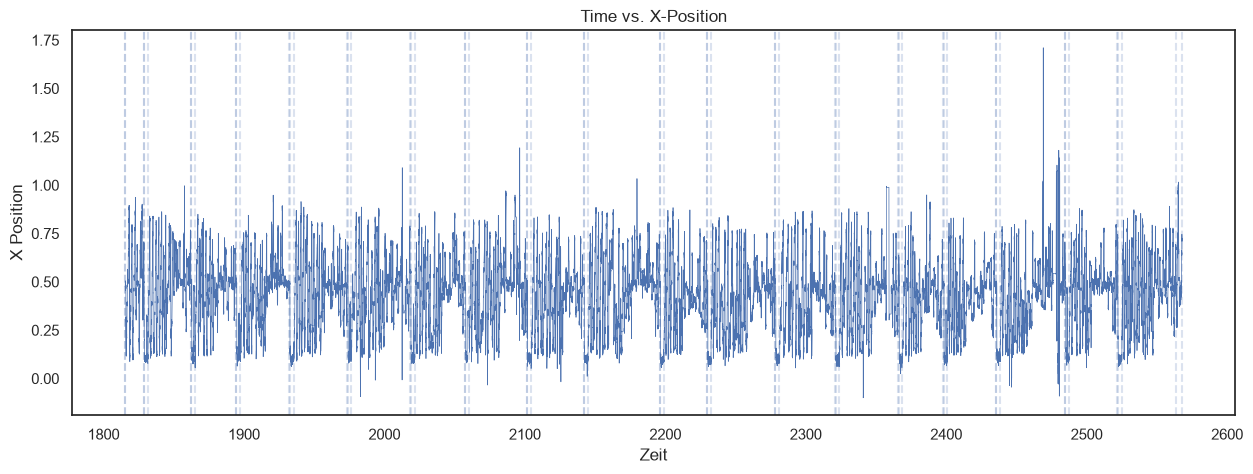

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    analysis_data["TIME"],
    analysis_data["BPOGX"],
    linewidth=0.5
)

for _, row in analysis_data.iterrows():

    if pd.notna(row["USER"]):

        plt.axvline(
            row["TIME"],
            alpha=0.2,
            linestyle="--"
        )

plt.xlabel("Zeit")
plt.ylabel("X Position")
plt.title("Time vs. X-Position")

plt.show()

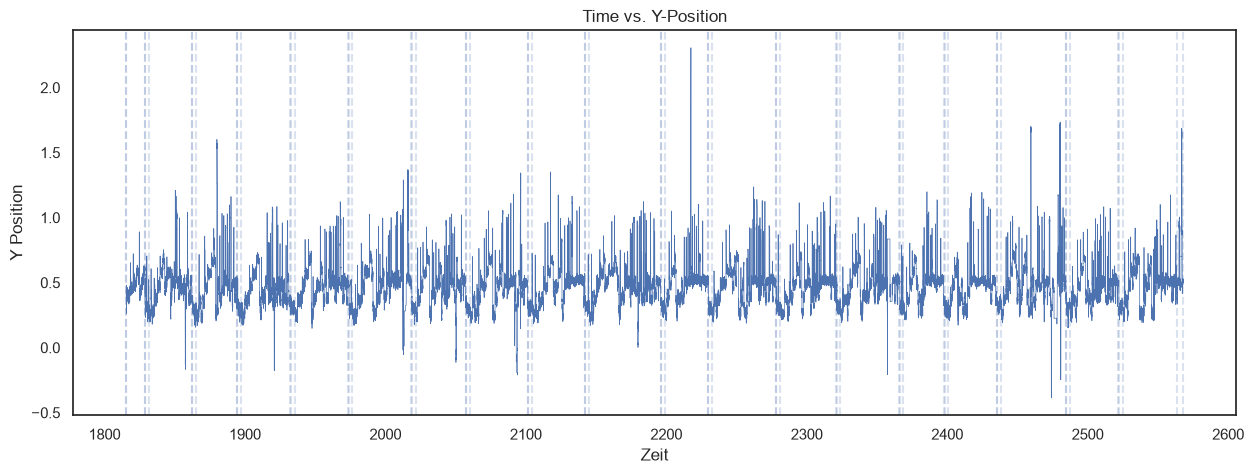

In [22]:
plt.figure(figsize=(15,5))

plt.plot(
    analysis_data["TIME"],
    analysis_data["BPOGY"],
    linewidth=0.5
)

for _, row in analysis_data.iterrows():

    if pd.notna(row["USER"]):

        plt.axvline(
            row["TIME"],
            alpha=0.2,
            linestyle="--"
        )

plt.xlabel("Zeit")
plt.ylabel("Y Position")
plt.title("Time vs. Y-Position")

plt.show()

             TIME               USER   delta_t
0      1815.46558                  0       NaN
1      1815.47205        START_TRIAL   0.00647
1955   1828.56091  INSTRUCTION_ONSET  13.08886
1973   1828.68127     FIXATION_ONSET   0.12036
2385   1831.44104     SENTENCE_ONSET   2.75977
7006   1862.39368         TEXT_ONSET  30.95264
7035   1862.58789     FIXATION_ONSET   0.19421
7419   1865.16003     SENTENCE_ONSET   2.57214
11796  1894.47827         TEXT_ONSET  29.31824
11824  1894.66565     FIXATION_ONSET   0.18738
12221  1897.32495     SENTENCE_ONSET   2.65930
17449  1932.34351         TEXT_ONSET  35.01856
17469  1932.47742     FIXATION_ONSET   0.13391
17893  1935.31750     SENTENCE_ONSET   2.84008
23614  1973.63818         TEXT_ONSET  38.32068
23650  1973.87927     FIXATION_ONSET   0.24109
24000  1976.22363     SENTENCE_ONSET   2.34436
30313  2018.50977         TEXT_ONSET  42.28614
30333  2018.64368     FIXATION_ONSET   0.13391
30751  2021.44348     SENTENCE_ONSET   2.79980


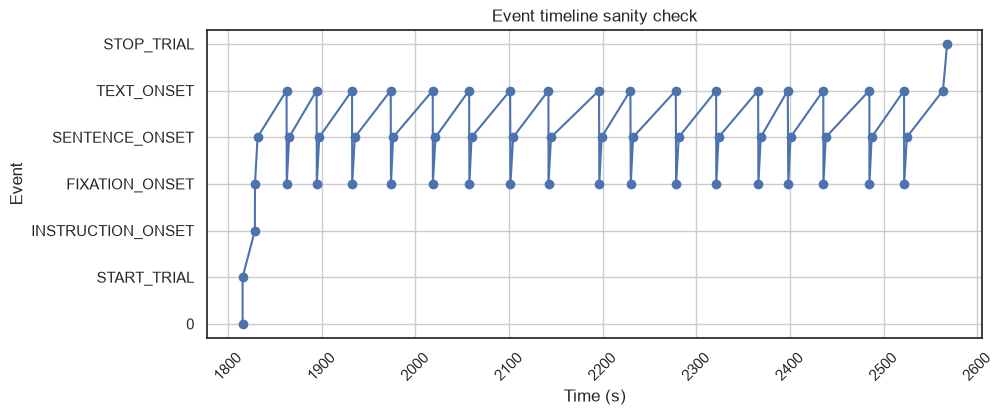

In [23]:
import pandas as pd

# only relevent events
logs = analysis_data[
    analysis_data["USER"].notna()
].copy()

# sort after time
logs = logs.sort_values("TIME")

# Timedifference
logs["delta_t"] = logs["TIME"].diff()

# Show event
print(logs[["TIME", "USER", "delta_t"]].head(20))
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(logs["TIME"], logs["USER"], marker="o")

plt.xticks(rotation=45)
plt.title("Event timeline sanity check")
plt.xlabel("Time (s)")
plt.ylabel("Event")

plt.grid(True)

plt.show()

In [24]:
width = 1920      # RESOLUTION
height = 1080

margin = 150
font_size = 39

box_width = width - (2 * margin)

text_start_x = -(box_width / 2)
text_start_y = -height / 2 + 250

cross_x = text_start_x
cross_y = text_start_y + (font_size / 2)

centre_x = width/2 + cross_x
centre_y = height/2 + cross_y

cross_x_norm = centre_x / width
cross_y_norm = centre_y / height

print(cross_x_norm, cross_y_norm)

0.078125 0.24953703703703703


FROM HERE WE USE DATA WITHOUT INVALID SAMPLES

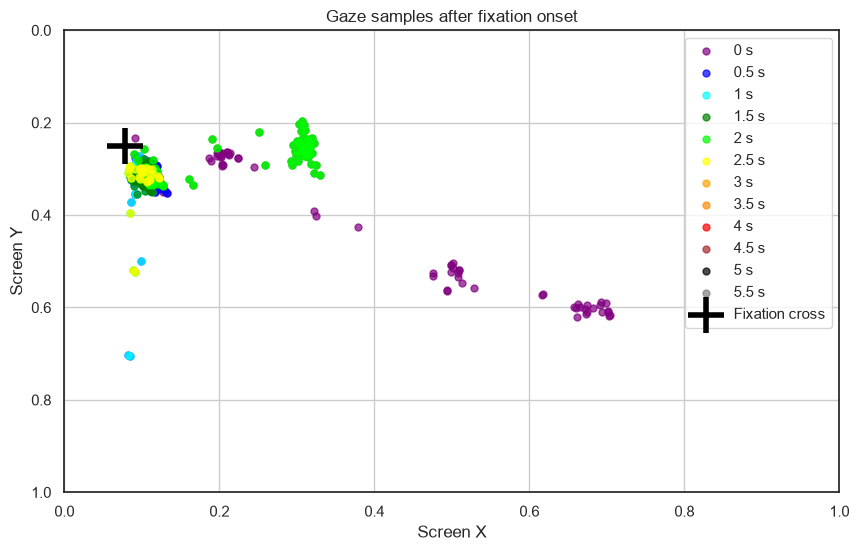

In [49]:
fixation_events = analysis_data[
    analysis_data["USER"] == "FIXATION_ONSET"
]

t0 = fixation_events["TIME"].iloc[0]

sentence_onset = analysis_data[
    (analysis_data["USER"] == "SENTENCE_ONSET") &
    (analysis_data["TIME"] > t0)
]["TIME"].iloc[0]

window = analysis_data[
    (analysis_data["TIME"] >= t0) &
    (analysis_data["TIME"] < sentence_onset)
].copy()



# Time for fixationcross
window["time_after_onset"] = window["TIME"] - t0

window = window[
    (window["BPOGV"] == 1) &
    (window["BPOGX"] >= 0) &
    (window["BPOGX"] <= 1) &
    (window["BPOGY"] >= 0) &
    (window["BPOGY"] <= 1)
]

# Resolution

SCREEN_W = 1920   
SCREEN_H = 1080

font_size = font_size
margin = 150

box_width = SCREEN_W - (2 * margin)

text_start_x = -(box_width / 2)
text_start_y = -SCREEN_H / 2 + 250

cross_x = text_start_x
cross_y = text_start_y + (font_size / 2)

centre_x = SCREEN_W / 2 + cross_x
centre_y = SCREEN_H / 2 + cross_y

cross_x_norm = centre_x / SCREEN_W
cross_y_norm = centre_y / SCREEN_H


plt.figure(figsize=(10, 6))


# different colors over time
colors = {
    0: "purple",
    0.5: "blue",
    1: "cyan",
    1.5: "green",
    2: "lime",  
    2.5: "yellow", 
    3: "orange", 
    3.5: "darkorange", 
    4: "red", 
    4.5: "brown",
    5: "black",
    5.5: "grey",     
}


# Gaze Points coloring
for ms, color in colors.items():

    samples = window[
        (window["time_after_onset"] >= ms) &
        (window["time_after_onset"] < ms + 1)
    ]

    plt.scatter(
        samples["BPOGX"],
        samples["BPOGY"],
        c=color,
        s=25,
        alpha=0.7,
        label=f"{ms} s"
    )


# Fixationcross
plt.scatter(
    cross_x_norm,
    cross_y_norm,
    c="black",
    marker="+",
    s=700,
    linewidths=4,
    label="Fixation cross"
)


plt.xlim(0,1)
plt.ylim(1,0)

plt.xlabel("Screen X")
plt.ylabel("Screen Y")
plt.title("Gaze samples after fixation onset")
plt.legend()
plt.grid(True)

plt.show()

    trial  n_samples  mean_dist_px  median_dist_px  std_dist_px
0       1        131     94.305528       88.958020    55.488093
1       2        149    421.549518      218.924932   311.644721
2       3        149    183.376938      110.018565   154.204724
3       4        149     76.784035       79.803437    22.880530
4       5        149    232.004766       81.711774   237.220424
5       6        149    153.630464       92.028755   164.091573
6       7        149    390.077060      493.957372   183.081048
7       8        149     91.065770       90.867717    31.796545
8       9        149     81.092951       78.902213    25.500447
9      10        149     75.643420       78.253671    25.635332
10     11        149     70.163078       72.467566    24.377180
11     12        136    115.159492       97.679751    95.837518
12     13        149     80.618363       82.262316    29.646647
13     14        134     84.507782       78.283103    81.850739
14     15        149    167.993318      

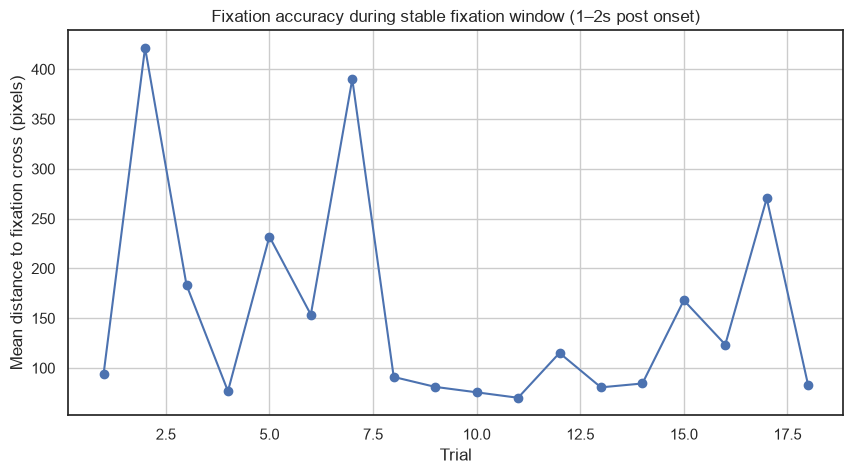

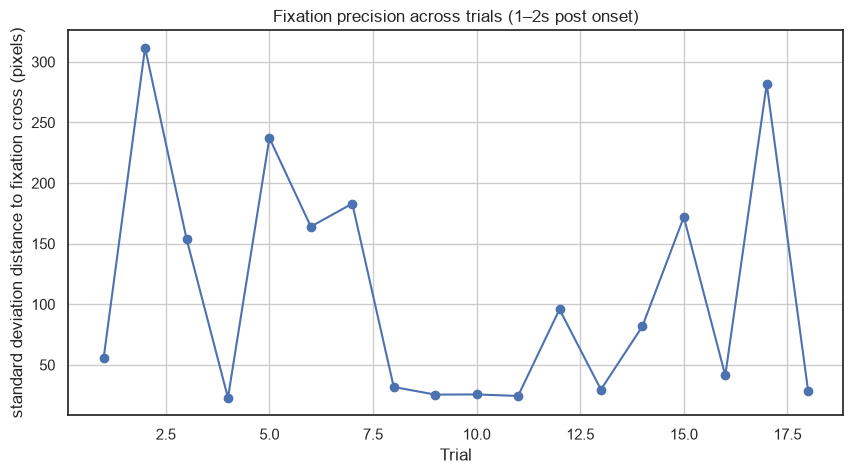

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

 
# Resolution
 

SCREEN_W = 1920
SCREEN_H = 1080

 
# Position of fixationcross
 

font_size = font_size
margin = 150

box_width = SCREEN_W - (2 * margin)

text_start_x = -(box_width / 2)
text_start_y = -SCREEN_H / 2 + 250

cross_x = text_start_x
cross_y = text_start_y + (font_size / 2)

centre_x = SCREEN_W / 2 + cross_x
centre_y = SCREEN_H / 2 + cross_y

cross_x_norm = centre_x / SCREEN_W
cross_y_norm = centre_y / SCREEN_H

 
# Fixation Events
 

fixation_events = analysis_data[
    analysis_data["USER"] == "FIXATION_ONSET"
].copy()

results = []

 
# Accuracy pro Fixation
 

for i, (_, fix) in enumerate(
    fixation_events.iterrows()
):

    t0 = fix["TIME"]

    # only use the first seconds:
    # 1s to 2s after Fixation-Onset

    next_sentence = analysis_data[
        (analysis_data["USER"] == "SENTENCE_ONSET") &
        (analysis_data["TIME"] > t0)
    ]

    if next_sentence.empty:
        continue

    sentence_onset = next_sentence["TIME"].iloc[0]

    window = analysis_data[
        (analysis_data["TIME"] >= t0 + 1.0) &
        (analysis_data["TIME"] < min(t0 + 2.0, sentence_onset))
    ].copy()

    # remove invalid samples

    window = window[
        (window["BPOGV"] == 1) &
        (window["BPOGX"] >= 0) &
        (window["BPOGX"] <= 1) &
        (window["BPOGY"] >= 0) &
        (window["BPOGY"] <= 1)
    ]

    if len(window) == 0:
        continue

    # Distanz to Fixationscross

    window["dist_px"] = np.sqrt(

        ((window["BPOGX"] - cross_x_norm) * SCREEN_W) ** 2 +

        ((window["BPOGY"] - cross_y_norm) * SCREEN_H) ** 2

    )

    results.append({

        "trial": i + 1,

        "n_samples": len(window),

        "mean_dist_px": window["dist_px"].mean(),

        "median_dist_px": window["dist_px"].median(),

        "std_dist_px": window["dist_px"].std()

    })

 
# Table
 

accuracy_df = pd.DataFrame(results)

print(accuracy_df)

 
# Summary
 

print("\nSummary:\n")

print(
    accuracy_df[
        [
            "mean_dist_px",
            "median_dist_px",
            "std_dist_px"
        ]
    ].describe()
)

 
# Plot
 

plt.figure(figsize=(10,5))

plt.plot(
    accuracy_df["trial"],
    accuracy_df["mean_dist_px"],
    marker="o"
)

plt.xlabel("Trial")
plt.ylabel("Mean distance to fixation cross (pixels)")
plt.title("Fixation accuracy during stable fixation window (1–2s post onset)")

plt.grid(True)

plt.show()

plt.figure(figsize=(10,5))

plt.plot(
    accuracy_df["trial"],
    accuracy_df["std_dist_px"],
    marker="o"
)

plt.xlabel("Trial")
plt.ylabel("standard deviation distance to fixation cross (pixels)")
plt.title("Fixation precision across trials (1–2s post onset)")

plt.grid(True)
plt.show()

Sentences OVER TIME DARSTELLUNG     

Keep in mind that matplot isnt rendering the sentences the same as opensesame so the sentences might not always be in the right position but the aois are.

rn_x1       370.0
rn_y1      -173.0
rn_x2       756.0
rn_y2      -120.0
an_x1      -131.0
an_y1        61.0
an_x2         1.0
an_y2       114.0
spill_x1      1.0
spill_y1     61.0
spill_x2    133.0
spill_y2    114.0
Name: 0, dtype: float64


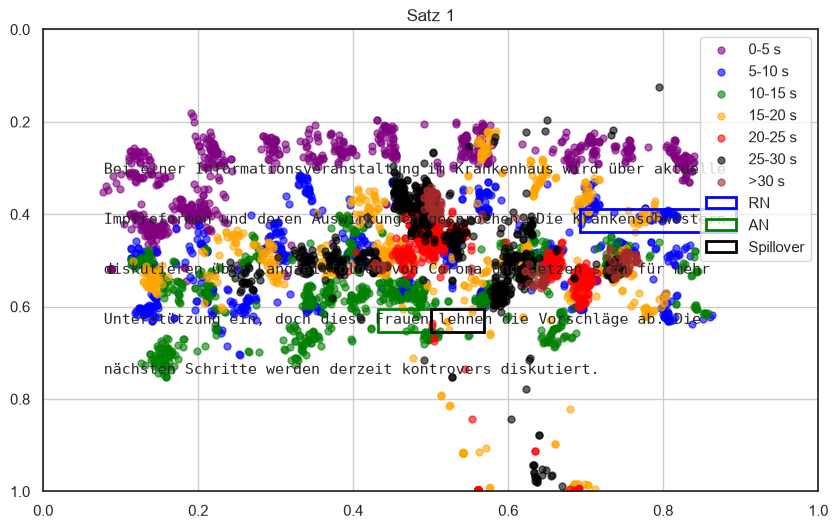

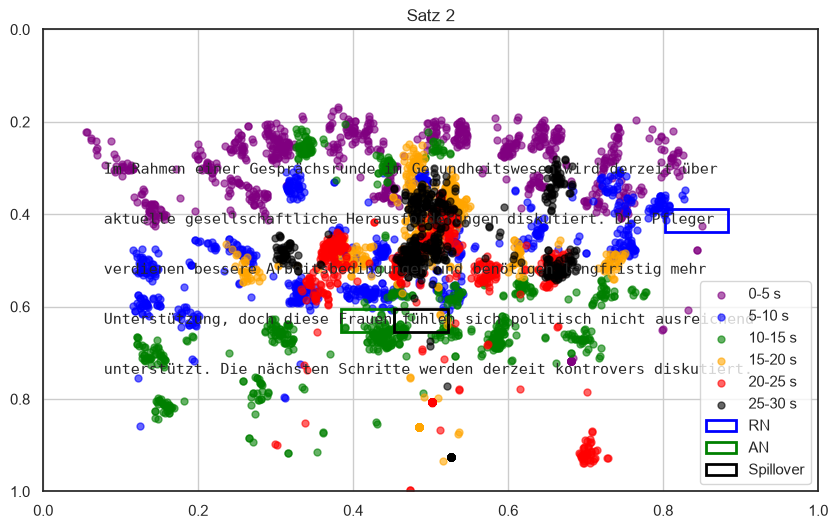

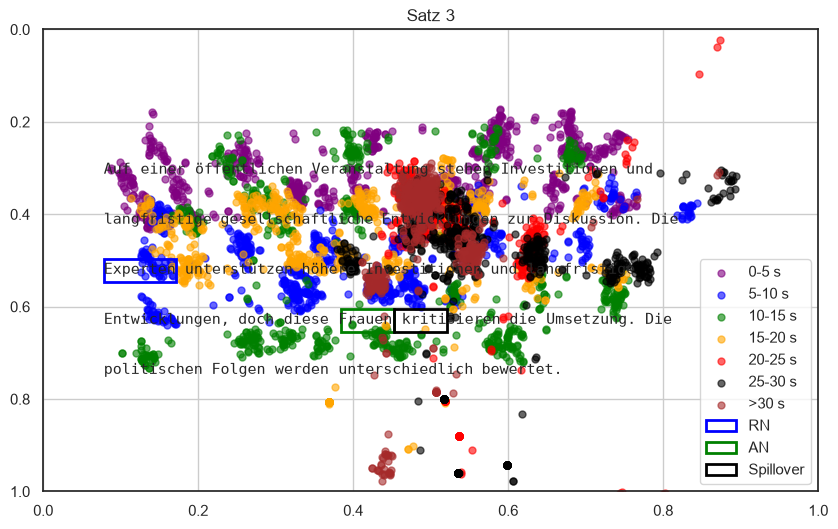

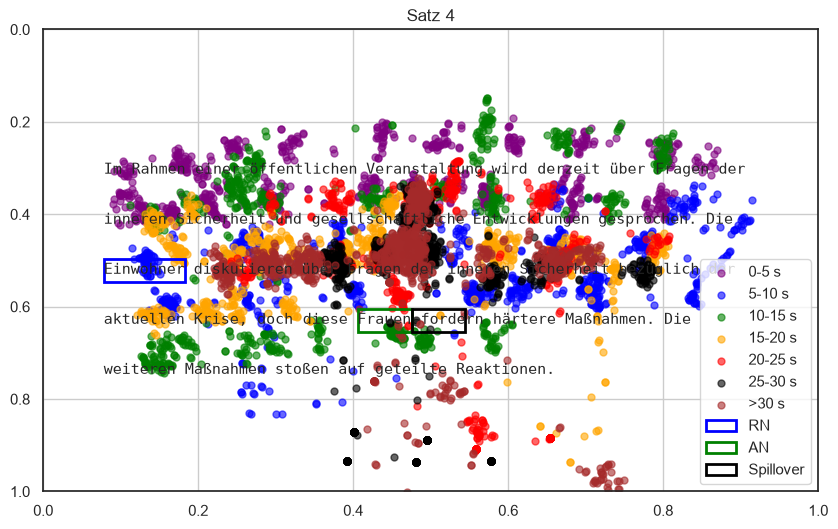

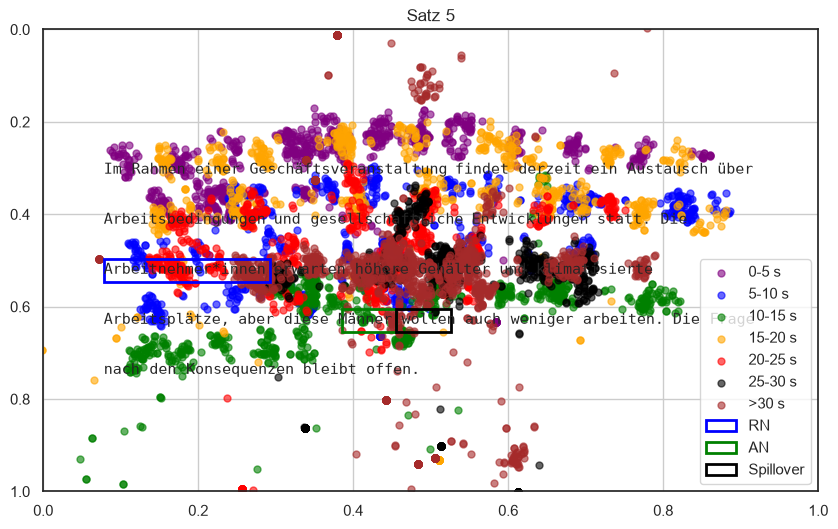

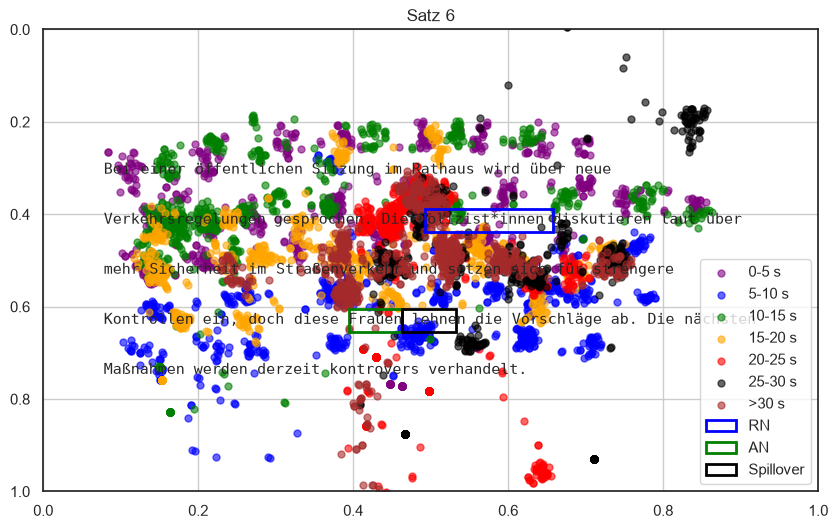

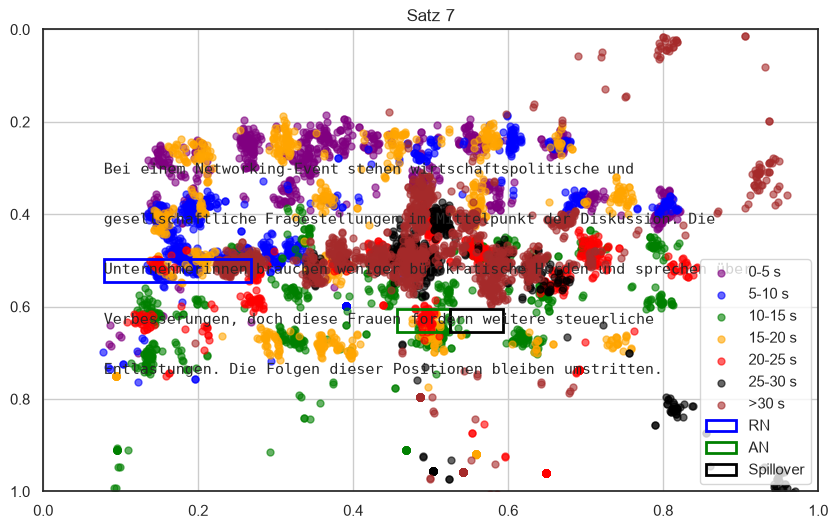

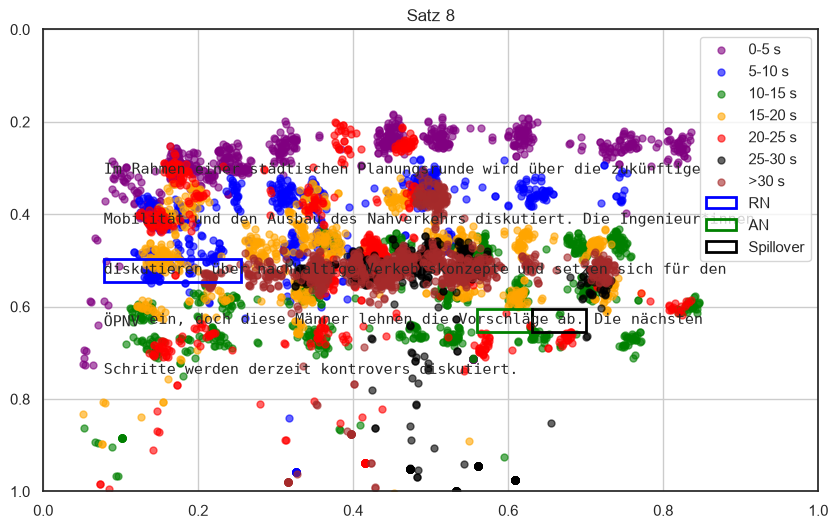

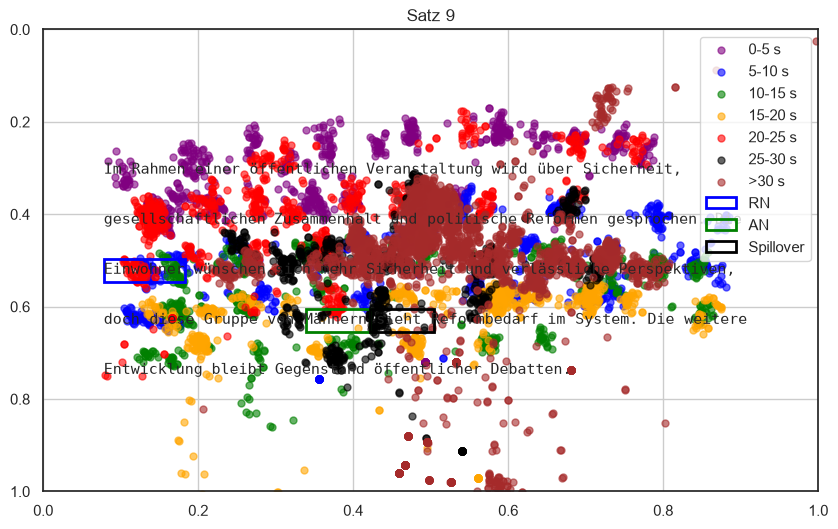

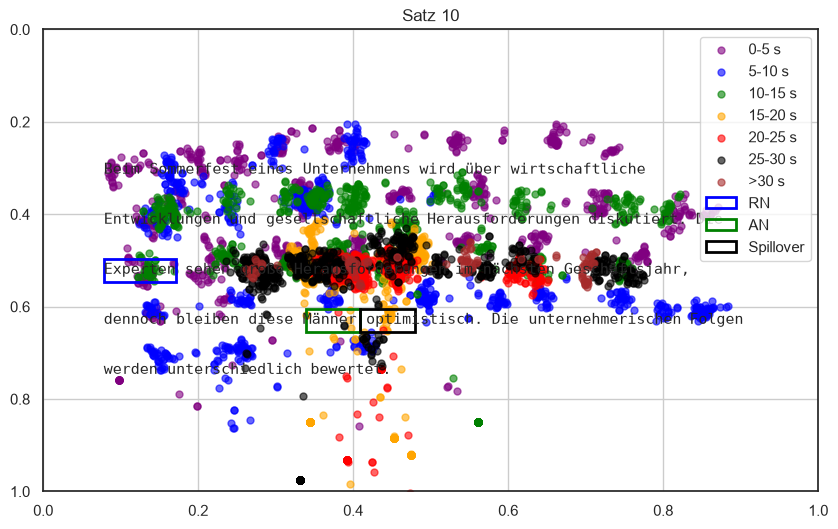

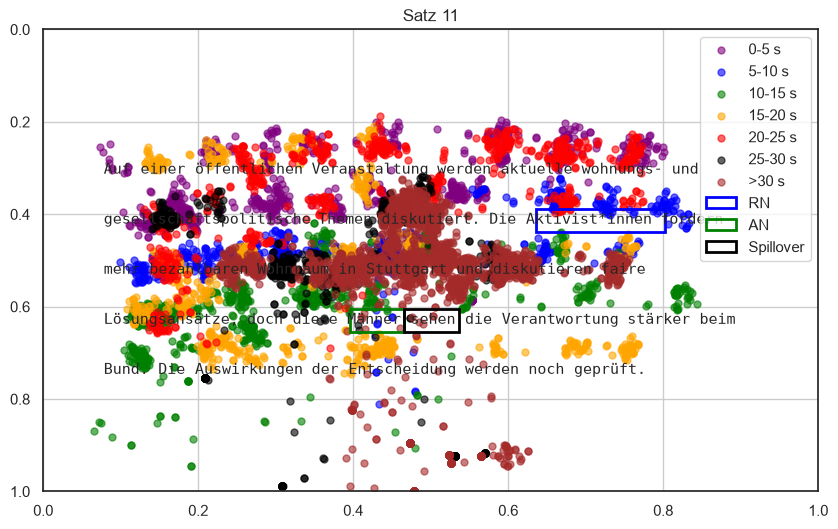

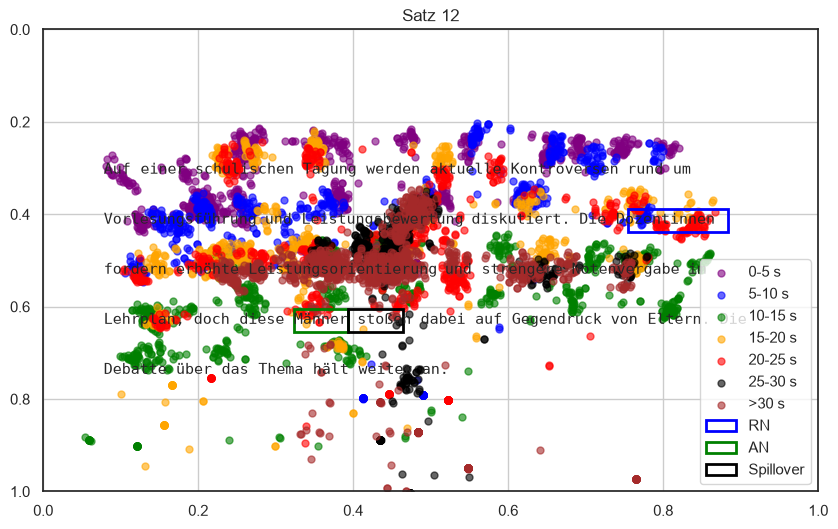

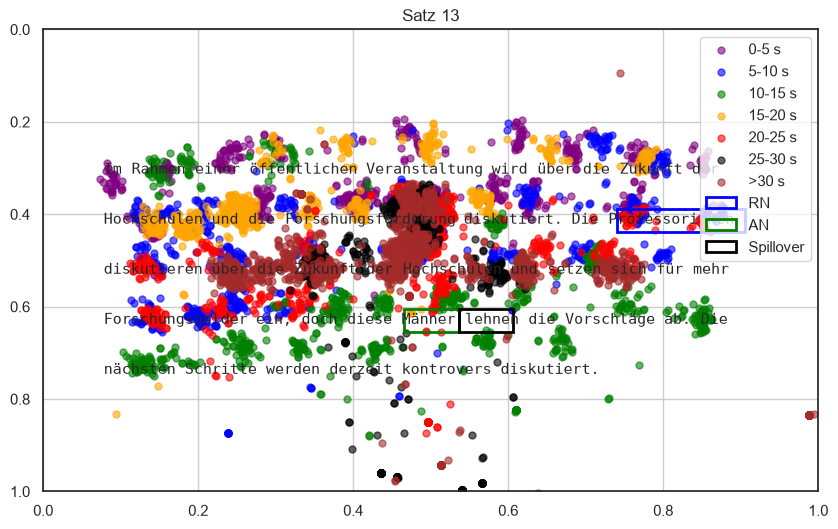

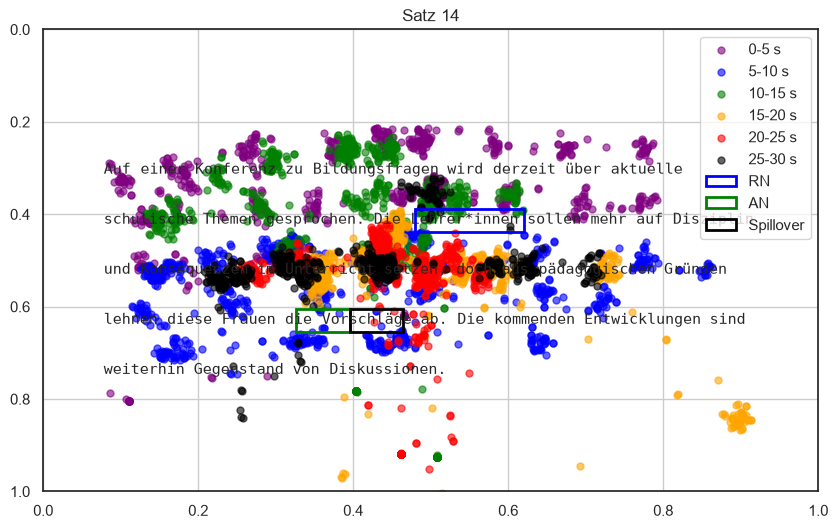

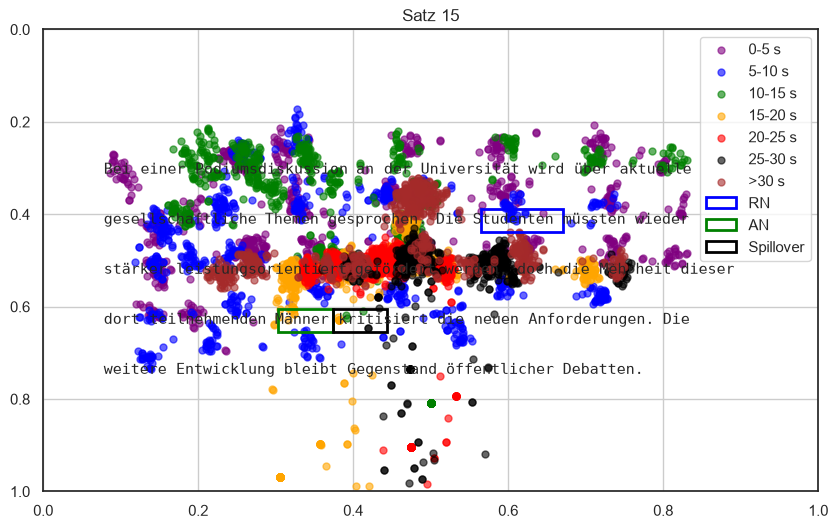

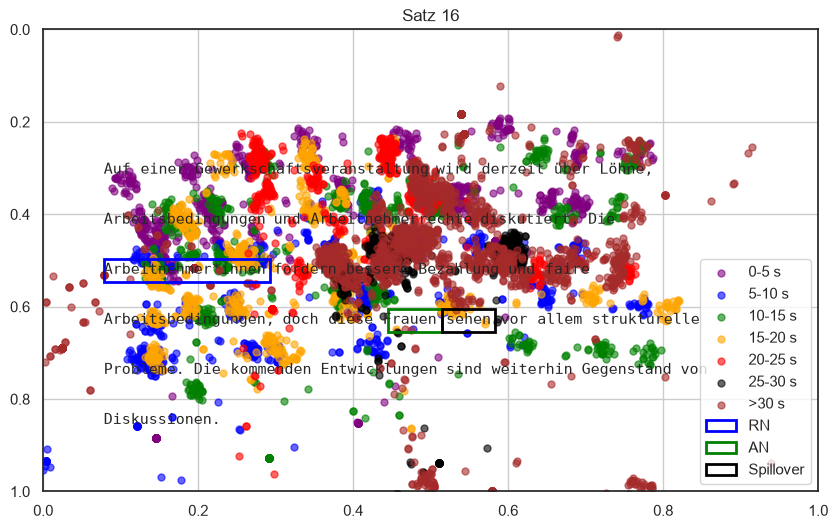

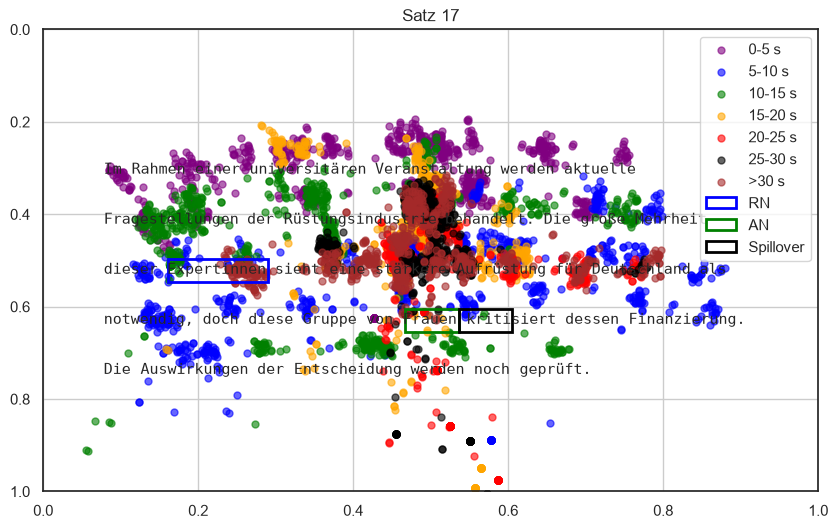

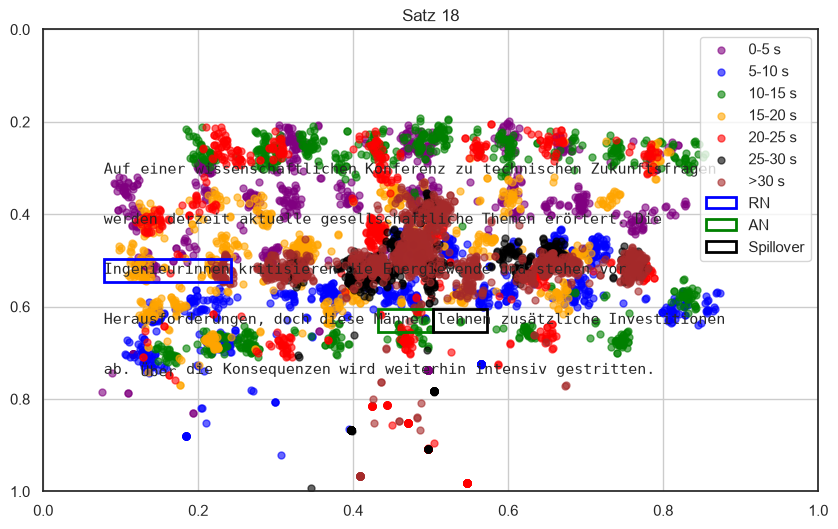

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# CSV loading
 
csv_path = "../data/raw/subject-1.csv"
trial_data = pd.read_csv(csv_path)

# Nur echte Trials behalten
trial_data = trial_data[trial_data["trial_counter"] > 0].reset_index(drop=True)


aoi_cols = [
    "rn_x1","rn_y1","rn_x2","rn_y2",
    "an_x1","an_y1","an_x2","an_y2",
    "spill_x1","spill_y1","spill_x2","spill_y2"
]

trial_data[aoi_cols] = (
    trial_data
    .groupby("trial_counter")[aoi_cols]
    .bfill()
)

sentence_data = (
    trial_data
    .drop_duplicates(subset="trial_counter")
    .reset_index(drop=True)
)
print(sentence_data.loc[0, [
    "rn_x1","rn_y1","rn_x2","rn_y2",
    "an_x1","an_y1","an_x2","an_y2",
    "spill_x1","spill_y1","spill_x2","spill_y2"
]])
 
# Events
 

sentence_events = analysis_data[
    analysis_data["USER"] == "SENTENCE_ONSET"
].copy()


text_events = analysis_data[
    analysis_data["USER"] == "TEXT_ONSET"
]

sentence_events = sentence_events.reset_index(drop=True)

 
# RN / AN Positionings
 

for col in [
    "rn_x1","rn_y1","rn_x2","rn_y2",
    "an_x1","an_y1","an_x2","an_y2",
    "spill_x1","spill_y1","spill_x2","spill_y2"
]:

    sentence_events[col] = sentence_data[col].iloc[:18].values


# RESOLUTION 1920 x 1080

SCREEN_W = 1920
SCREEN_H = 1080


font_size = 39
word_spacing = 25

margin = 150

box_width = SCREEN_W - 2*margin


line_spacing = font_size * 3

 
# Koordinates
 
def conv_x(x):

    return (
        SCREEN_W/2 + x
    ) / SCREEN_W


def conv_y(y):

    return (
        SCREEN_H/2 + y
    ) / SCREEN_H

# Sentences
 
for i, (_, event) in enumerate(
    sentence_events.iloc[:18].iterrows()
):


    t0 = event["TIME"]



    next_text = text_events[
        text_events["TIME"] > t0
    ]


    if len(next_text)==0:
        continue



    t1 = next_text["TIME"].iloc[0]



    window = analysis_data[
        (analysis_data["TIME"] >= t0) &
        (analysis_data["TIME"] < t1)
    ].copy()

    plt.figure(figsize=(10,6))


    plt.xlim(0,1)
    plt.ylim(1,0)

      
    # Sentences
      
    import re

    sentence = sentence_data.loc[i,"sentence_text"]


    rn_text = str(sentence_data.loc[i,"RN"])
    an_text = str(sentence_data.loc[i,"AN"])

    # RN / AN Tags removal
    rn_text = re.sub(
        r"<RN>|</RN>",
        "",
        rn_text
    )

    an_text = re.sub(
        r"<AN>|</AN>",
        "",
        an_text
    )

    # text between the tags

    sentence = re.sub(
        r"<RN>.*?</RN>",
        rn_text,
        sentence
    )


    sentence = re.sub(
        r"<AN>.*?</AN>",
        an_text,
        sentence
    )



    sentence = sentence.replace(
        "<RN>",
        rn_text
    ).replace(
        "</RN>",
        ""
    )


    sentence = sentence.replace(
        "<AN>",
        an_text
    ).replace(
        "</AN>",
        ""
    )

    words = sentence.split()

    position_x = -(box_width/2)

    position_y = -SCREEN_H/2 + 310

    for word in words:


        # try to get the text the same size
        word_width = len(word) * 22



        current_width = (
            position_x + box_width/2
        )

        if current_width + word_width > box_width:


            position_x = -(box_width/2)

            position_y += line_spacing

        plt.text(

            conv_x(position_x),

            conv_y(position_y),

            word,

            fontsize=11,

            family="monospace",

            ha="left",

            va="top"

        )

        position_x += (
            word_width + word_spacing
        )


    # Gaze colored over reading time
      

    window["time_after"] = window["TIME"] - t0


    bins = [0, 5, 10, 15, 20, 25, 30]

    colors = [
        "purple",
        "blue",
        "green",
        "orange",
        "red",
        "black"
    ]


    for j in range(len(bins)-1):

        samples = window[
            (window["time_after"] >= bins[j]) &
            (window["time_after"] < bins[j+1])
        ]

        plt.scatter(
            samples["BPOGX"],
            samples["BPOGY"],
            color=colors[j],
            s=25,
            alpha=0.6,
            label=f"{bins[j]}-{bins[j+1]} s"
        )


    # If Sentences were read longer than 30 seconds
    samples = window[
        window["time_after"] >= 30
    ]

    if len(samples) > 0:

        plt.scatter(
            samples["BPOGX"],
            samples["BPOGY"],
            color="brown",
            s=25,
            alpha=0.6,
            label=">30 s"
        )
       
     
    # RN Box 
     

    if pd.notna(event["rn_x1"]):

        rn = patches.Rectangle(

            (
                conv_x(event["rn_x1"]),
                conv_y(event["rn_y2"])
            ),

            (event["rn_x2"] - event["rn_x1"]) / SCREEN_W,

            (event["rn_y2"] - event["rn_y1"]) / SCREEN_H,

            fill=False,

            linewidth=2,

            edgecolor="blue",

            label="RN"

        )


        plt.gca().add_patch(rn)

    # AN Box 
     

    if pd.notna(event["an_x1"]):

        an = patches.Rectangle(

            (
                conv_x(event["an_x1"]),
                conv_y(event["an_y2"])
            ),

            (event["an_x2"] - event["an_x1"]) / SCREEN_W,

            (event["an_y2"] - event["an_y1"]) / SCREEN_H,

            fill=False,

            linewidth=2,

            edgecolor="green",

            label="AN"

        )

        plt.gca().add_patch(an)

    if pd.notna(event["spill_x1"]):

        spill = patches.Rectangle(

            (
                conv_x(event["spill_x1"]),
                conv_y(event["spill_y2"])
            ),

            (event["spill_x2"] - event["spill_x1"]) / SCREEN_W,

            (event["spill_y2"] - event["spill_y1"]) / SCREEN_H,

            fill=False,

            linewidth=2,

            edgecolor="black",


            label="Spillover"

        )

        plt.gca().add_patch(spill)

    plt.title(
        f"Satz {i+1}"
    )

    plt.legend()

    plt.grid()

    plt.show()

In [48]:
print(sentence_data.loc[0, [
    "font_size",
    "word_spacing",
    "word_width",
    "word_height",
    "width",
    "height"
]])
print(sentence_data.loc[2,[
    "rn_x1","rn_y1","rn_x2","rn_y2",
    "an_x1","an_y1","an_x2","an_y2"
]])

font_size         39.0
word_spacing      25.0
word_width       243.0
word_height       53.0
width           1920.0
height          1080.0
Name: 0, dtype: float64
rn_x1   -810.0
rn_y1    -56.0
rn_x2   -631.0
rn_y2     -3.0
an_x1   -223.0
an_y1     61.0
an_x2    -91.0
an_y2    114.0
Name: 2, dtype: float64


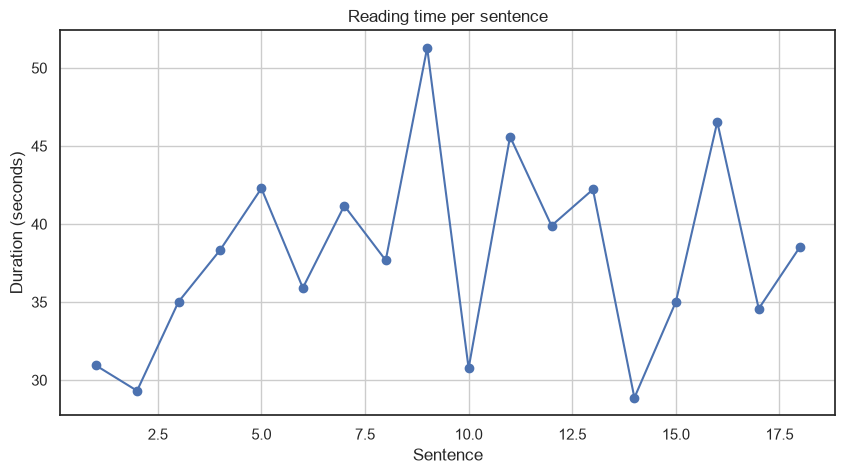

In [28]:
import matplotlib.pyplot as plt

durations = []
sentence_ids = []

for i, (_, event) in enumerate(sentence_events.iterrows()):

    t0 = event["TIME"]

    next_text = text_events[text_events["TIME"] > t0]

    if len(next_text) == 0:
        continue

    t1 = next_text["TIME"].iloc[0]

    # Only valid samples
    valid_samples = analysis_data[
        (analysis_data["TIME"] >= t0) &
        (analysis_data["TIME"] < t1) &
        (analysis_data["BPOGV"] == 1)
    ]

    if valid_samples.empty:
        continue

    durations.append(t1 - t0)
    sentence_ids.append(i + 1)

plt.figure(figsize=(10,5))
plt.plot(sentence_ids, durations, marker="o")
plt.xlabel("Sentence")
plt.ylabel("Duration (seconds)")
plt.title("Reading time per sentence")
plt.grid(True)
plt.show()

GO Past Time

In [29]:
def go_past_time(window, x1, y1, x2, y2, exit_x=None):

    window = window.sort_values("TIME").reset_index(drop=True)

    x_min = conv_x(x1)
    x_max = conv_x(x2)

    y_top = conv_y(y2)
    y_bottom = conv_y(y1)

    y_min = min(y_top, y_bottom)
    y_max = max(y_top, y_bottom)

    inside = (
        (window["BPOGX"] >= x_min) &
        (window["BPOGX"] <= x_max) &
        (window["BPOGY"] >= y_min) &
        (window["BPOGY"] <= y_max)
    )

    if not inside.any():
        return np.nan

    first = inside.idxmax()

    start_time = window.loc[first, "TIME"]

    if exit_x is None:
        exit_x = x2

    right_border = conv_x(exit_x)

    for i in range(first + 1, len(window)):

        if window.loc[i, "BPOGX"] > right_border:
            return window.loc[i, "TIME"] - start_time

    return window.iloc[-1]["TIME"] - start_time

rn_gpt = go_past_time(
    window,
    event["rn_x1"],
    event["rn_y1"],
    event["rn_x2"],
    event["rn_y2"]
)
an_gpt = go_past_time(
    window,
    event["an_x1"],
    event["an_y1"],
    event["spill_x2"],      # AOI till end of Spillover
    event["an_y2"],
    exit_x=event["spill_x2"]
)

results = []

for i, (_, event) in enumerate(sentence_events.iloc[:19].iterrows()):

    ...

    rn_gpt = go_past_time(
        window,
        event["rn_x1"],
        event["rn_y1"],
        event["rn_x2"],
        event["rn_y2"]
    )

    
    an_gpt = go_past_time(
    window,
    min(event["an_x1"], event["spill_x1"]),
    min(event["an_y1"], event["spill_y1"]),
    max(event["an_x2"], event["spill_x2"]),
    max(event["an_y2"], event["spill_y2"]),
    exit_x=max(event["an_x2"], event["spill_x2"])
    )

    results.append({
        "sentence": i + 1,
        "RN_GPT": rn_gpt,
        "AN_GPT": an_gpt
    })

results = pd.DataFrame(results)
print(results)

    sentence    RN_GPT   AN_GPT
0          1       NaN      NaN
1          2  35.88208  0.56250
2          3  29.88769  0.56250
3          4   0.13379  0.56250
4          5   0.05347  0.56250
5          6   0.34155  0.56250
6          7   0.23437  0.56250
7          8   0.34155  0.56250
8          9   0.34155  0.90430
9         10   0.05347  0.76343
10        11   0.13379  0.30176
11        12   2.68579  0.56250
12        13  30.06176  0.22119
13        14  34.61621  0.54932
14        15   0.40844  0.22119
15        16   0.20093  0.20801
16        17   0.34155  0.56250
17        18   0.34155  0.54932


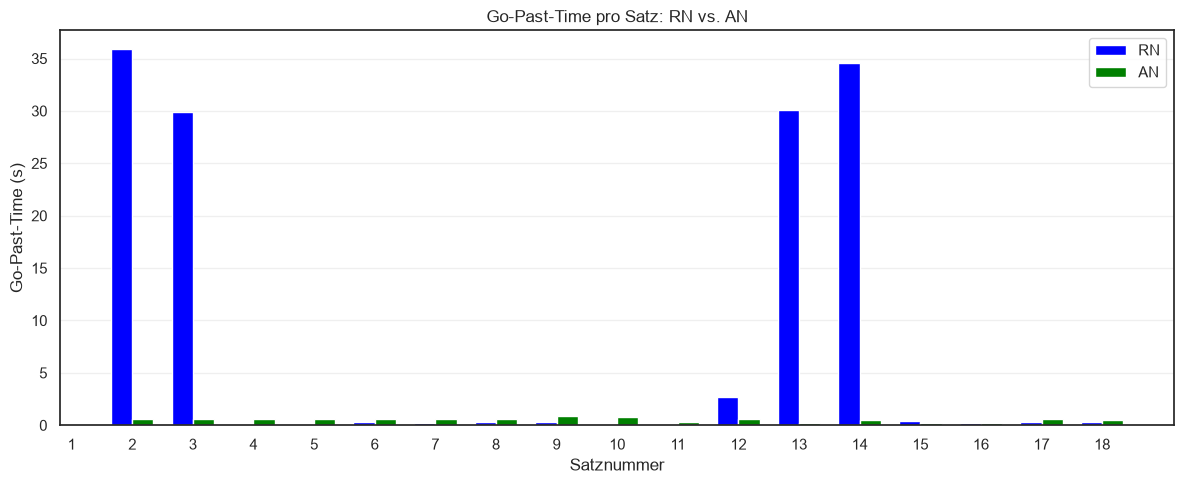

In [30]:
import matplotlib.pyplot as plt
import numpy as np

df = results.copy()

sentences = df["sentence"]

x = np.arange(len(sentences))

bar_width = 0.35

plt.figure(figsize=(12,5))

# RN Balken
plt.bar(
    x - bar_width/2,
    df["RN_GPT"],
    width=bar_width,
    label="RN",
    color="blue"
)

# AN Balken
plt.bar(
    x + bar_width/2,
    df["AN_GPT"],
    width=bar_width,
    label="AN",
    color="green"
)


plt.xticks(
    x,
    sentences
)

plt.xlabel("Satznummer")
plt.ylabel("Go-Past-Time (s)")

plt.title("Go-Past-Time pro Satz: RN vs. AN")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()